# mejiro strong-lens inference with PCAT

mejiro (Wedig et al.) renders the SLSim galaxy-galaxy lens `SampleGG` in the Roman Wide Field Instrument (WFI) F129 band, using its Roman point-spread function (PSF) width, zero point, and minimum zodiacal plus thermal sky. PCAT then samples the singular isothermal ellipsoid (SIE) lens, external shear, and source position from one Poisson exposure. Its likelihood reuses the lenstronomy model that mejiro built, so the data and the model share one definition. Four chains start from random prior draws and anneal the likelihood during burn-in.

Each chain runs 60,000 sweeps, of which the first 40,000 are burn-in. A second fit of the same exposure assumes a PSF 30% wider than the one mejiro used. Both runs take about four minutes on four cores.

In [1]:
from tdpy.verbosity import print as narrate
from pathlib import Path
import importlib.util
from IPython.display import Image, display

candidates = (
    root / 'examples/mejiro_roman_strong_lens/mejiro_roman_strong_lens.py'
    for root in (Path.cwd(), *Path.cwd().parents)
)
script = next(path for path in candidates if path.is_file())
narrate(f'Reading from {script}...')
specification = importlib.util.spec_from_file_location('mejiro_lens_example', script)
module = importlib.util.module_from_spec(specification)
specification.loader.exec_module(module)

summary = module.run_example()
for label, truth, median, stdv in zip(module.LABELS, summary['true_parameters'],
                                      summary['posterior_medians'], summary['posterior_stdvs']):
    print(f'{label}: injected {truth:+.4f}, posterior {median:+.4f} +/- {stdv:.4f}')
print(f"Maximum Gelman-Rubin R-hat {summary['maximum_rhat']:.3f}")
print(f"Wide PSF: largest offset {max(abs(summary['pulls_mismodeled'])):.1f} posterior std, "
      f"log-likelihood change {summary['delta_log_likelihood']:.0f}")

Reading from pcat/examples/mejiro_roman_strong_lens/mejiro_roman_strong_lens.py...


AstroMusers/mejiro/mejiro/synthetic_image.py:243: UserWarning: Supersampling factor less than 5 may not be sufficient for accurate results, especially when convolving with a non-trivial PSF
  warnings.warn('Supersampling factor less than 5 may not be sufficient for accurate results, especially when convolving with a non-trivial PSF')


$\theta_{\rm E}$ [arcsec]: injected +1.1681, posterior +1.1666 +/- 0.0018
Lens $e_1$: injected +0.0049, posterior +0.0060 +/- 0.0036
Lens $e_2$: injected +0.0075, posterior +0.0071 +/- 0.0044
Lens x [arcsec]: injected -0.0079, posterior -0.0091 +/- 0.0024
Lens y [arcsec]: injected +0.0106, posterior +0.0091 +/- 0.0023
Shear $\gamma_1$: injected -0.0365, posterior -0.0356 +/- 0.0017
Shear $\gamma_2$: injected -0.0651, posterior -0.0663 +/- 0.0023
Source x [arcsec]: injected +0.3030, posterior +0.3014 +/- 0.0023
Source y [arcsec]: injected -0.3505, posterior -0.3530 +/- 0.0024
Maximum Gelman-Rubin R-hat 1.088
Wide PSF: largest offset 3.5 posterior std, log-likelihood change -1485


## Image fit and parameter recovery

The left panels compare the mejiro exposure with the PCAT posterior-median model. The residual is in units of the Poisson standard deviation. The histograms compare retained samples from all chains with the injected mejiro parameters. The animation shows replicated exposures with fixed noise, from the initial prior draw through burn-in to posterior samples.

The last figure shows mismodeling. With the 30% wider PSF, the posteriors stay as narrow as with the correct PSF, but the Einstein radius, lens ellipticity, external shear, and source position move by 2 to 3 posterior standard deviations from the injected values. Only the drop in the best log likelihood reveals the wrong PSF.

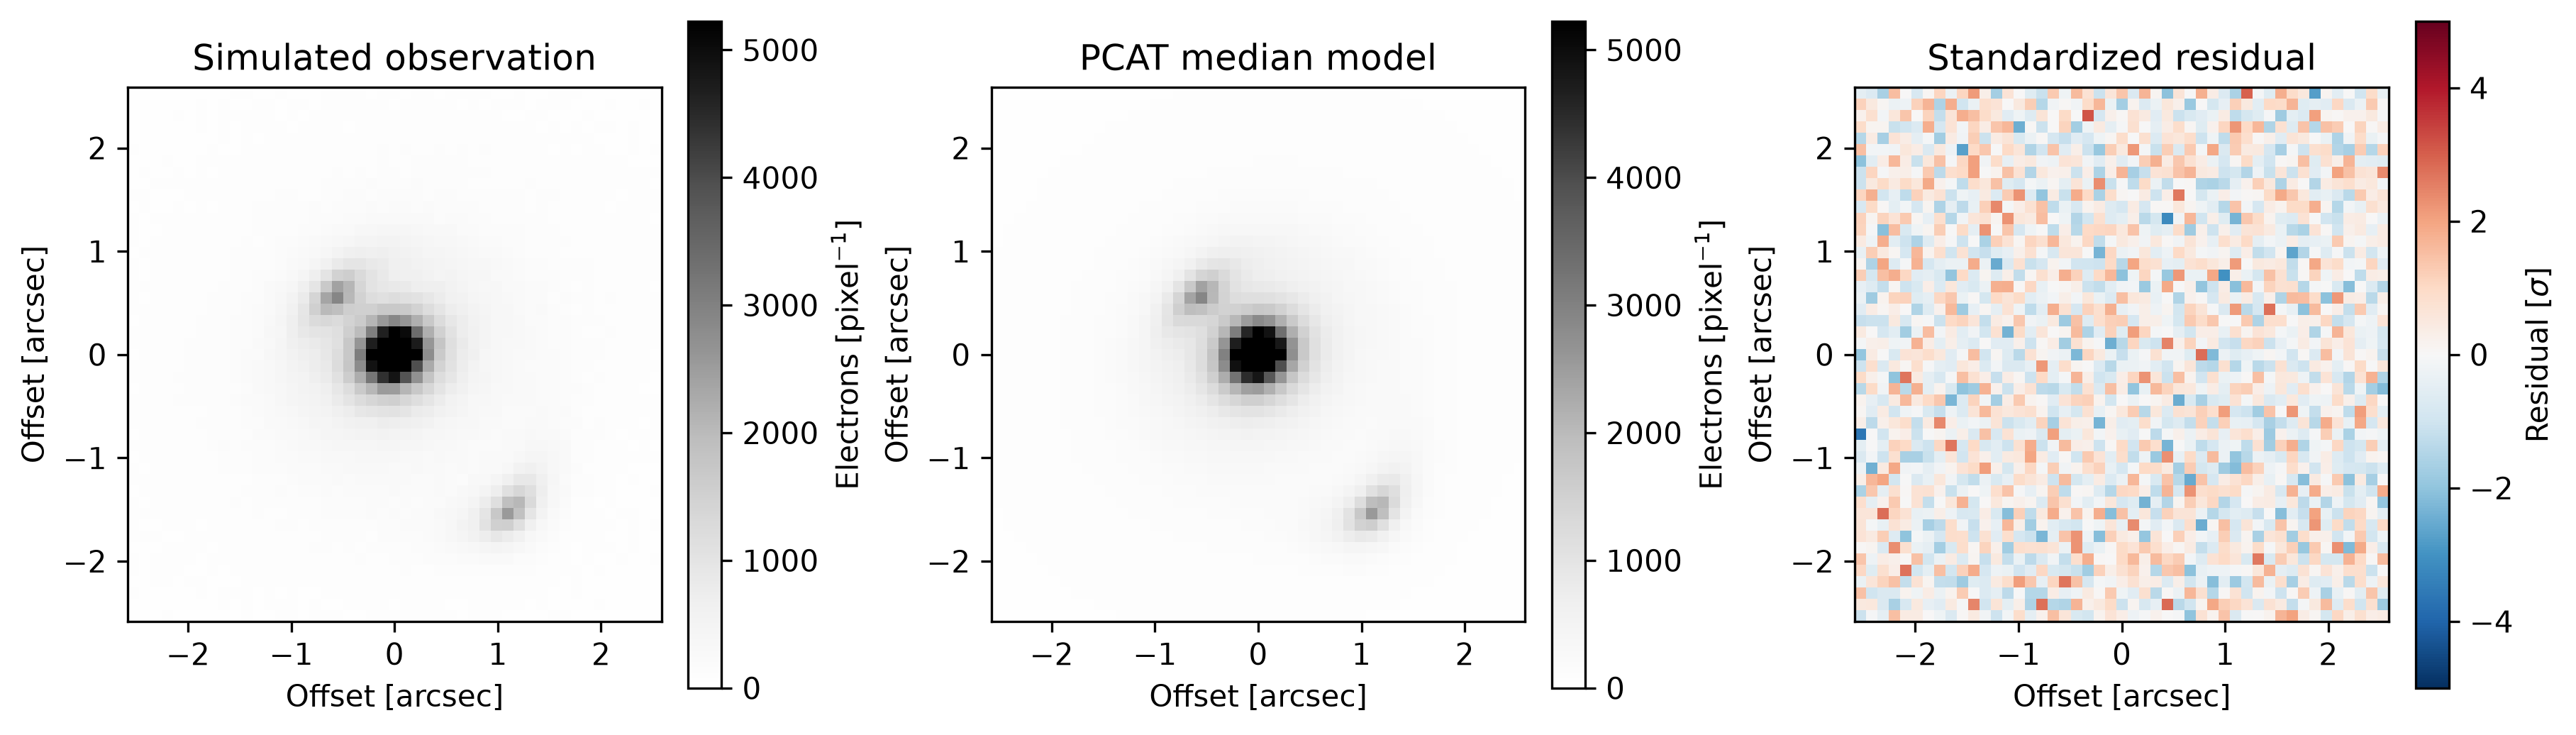

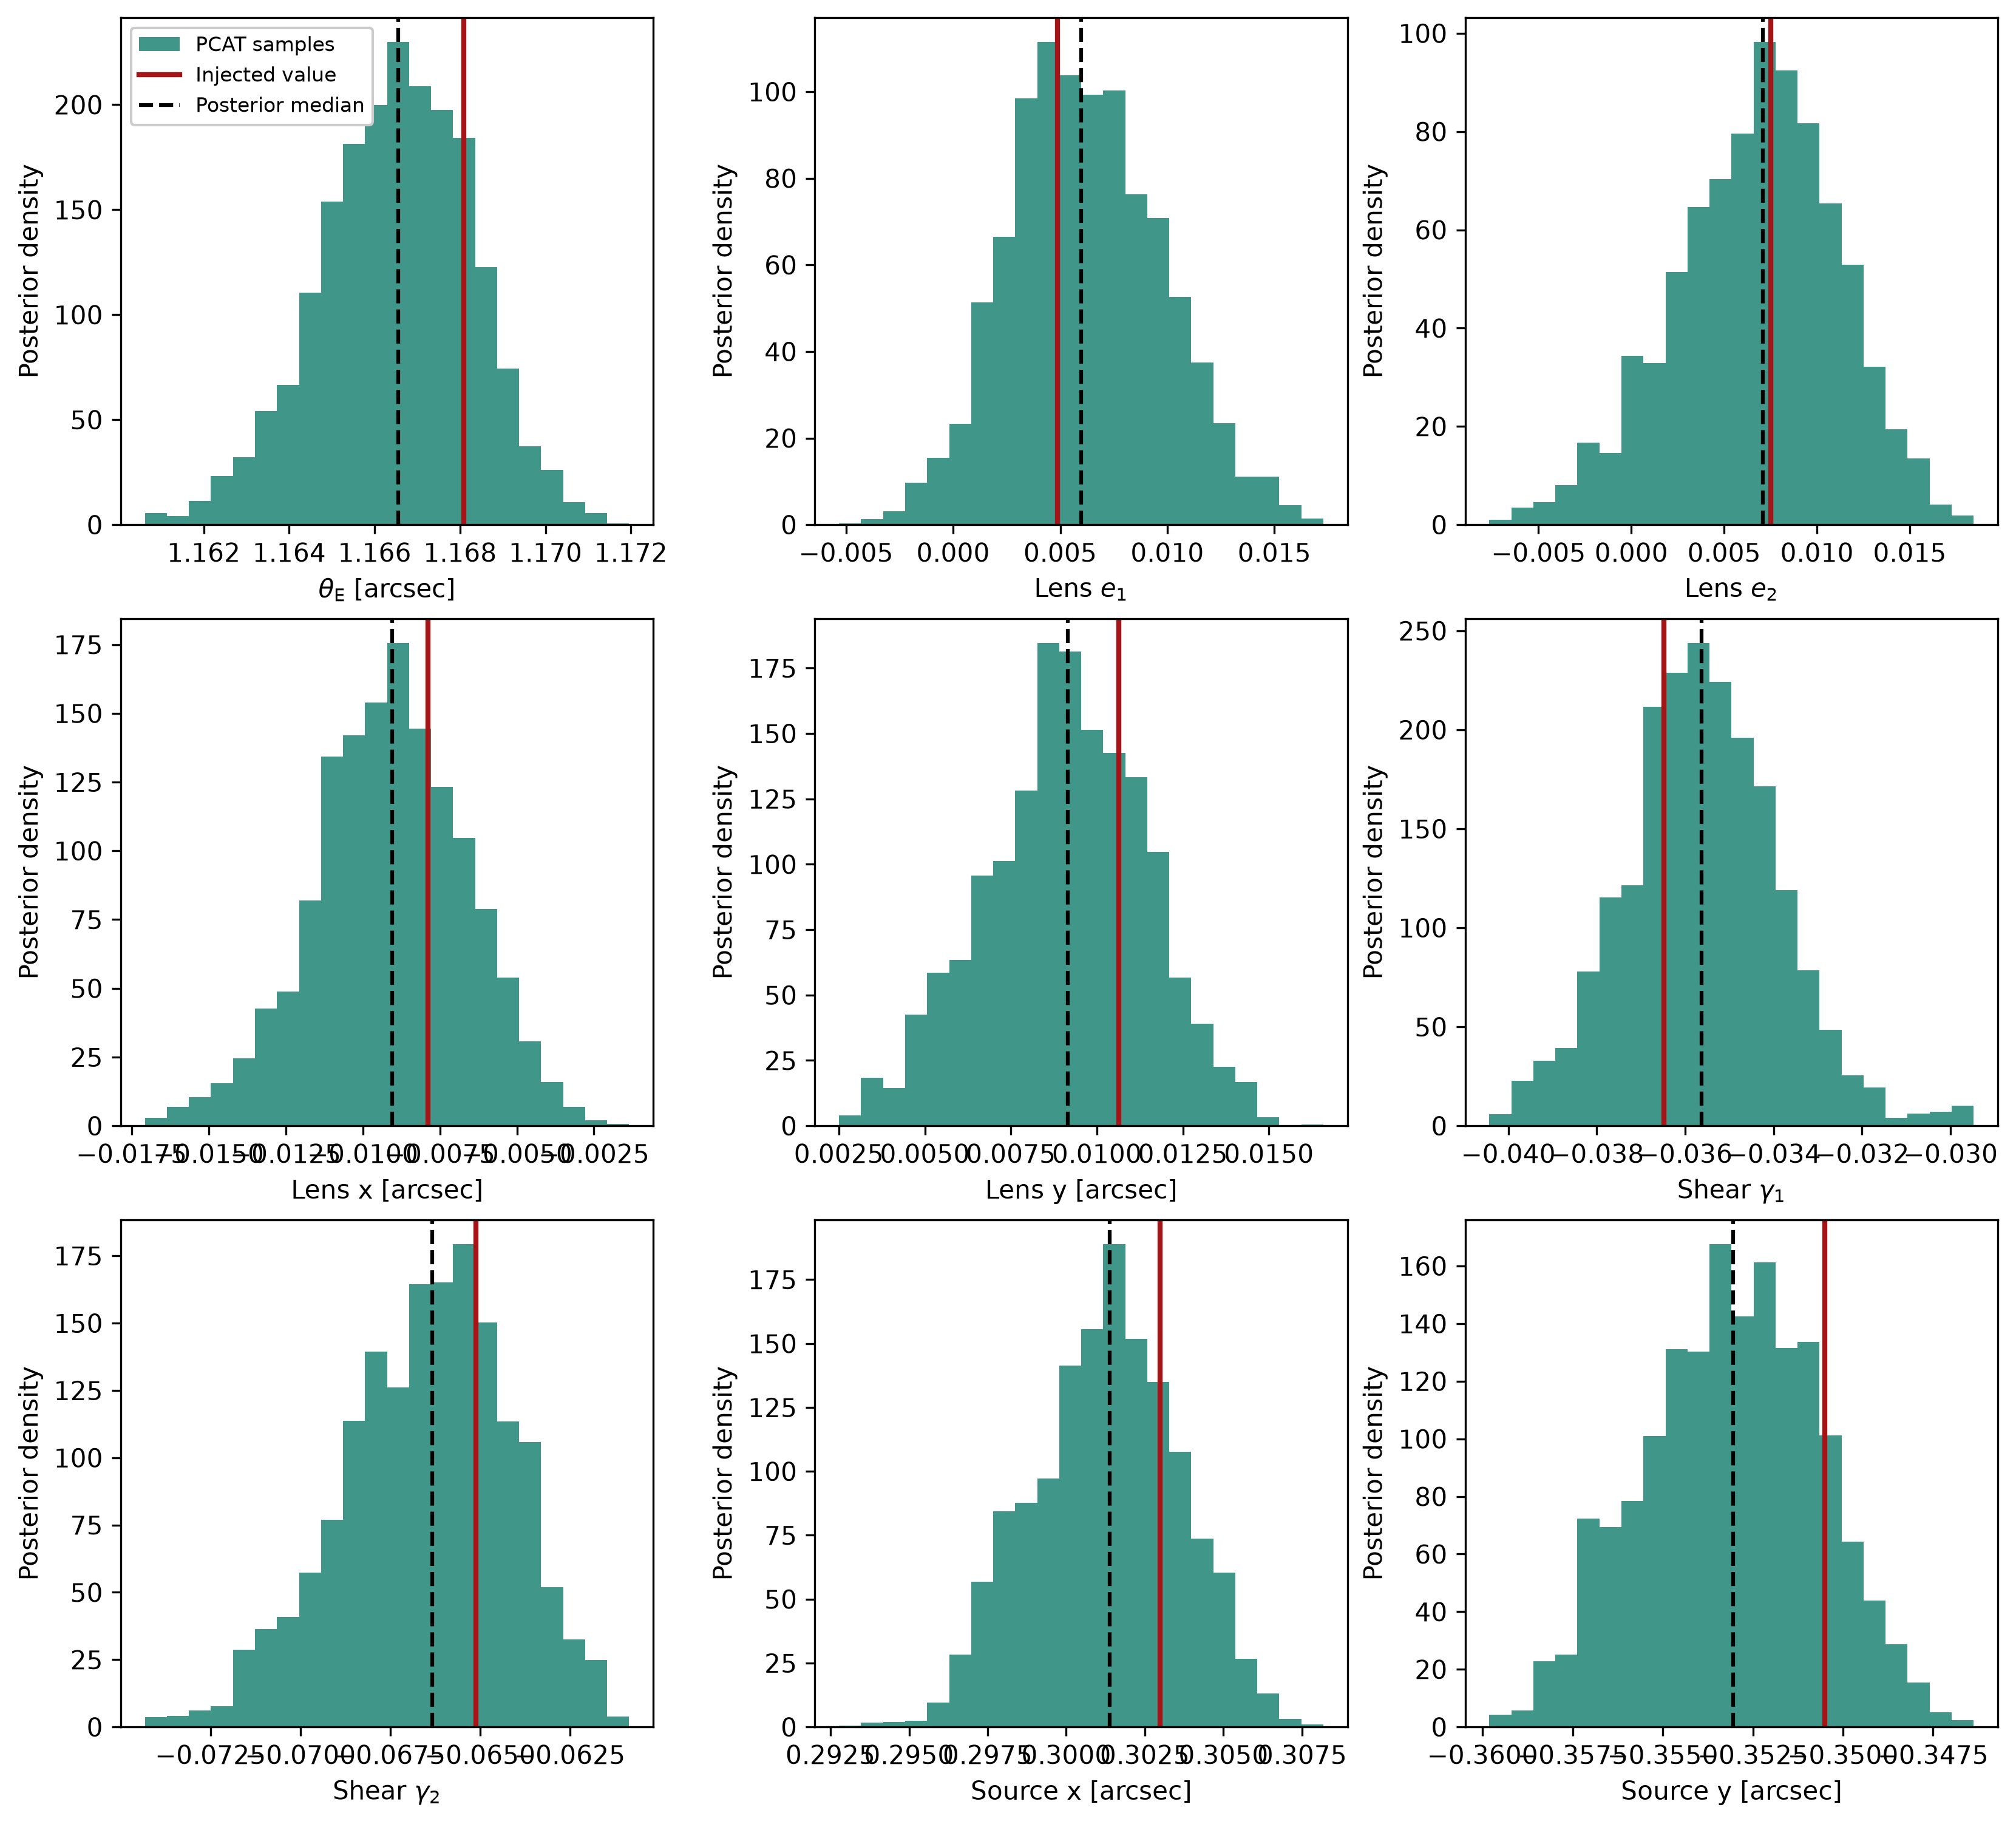

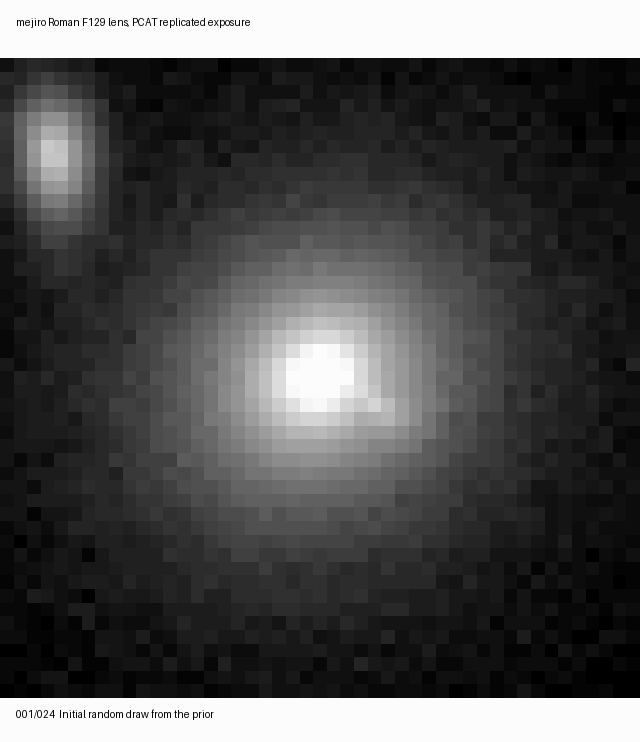

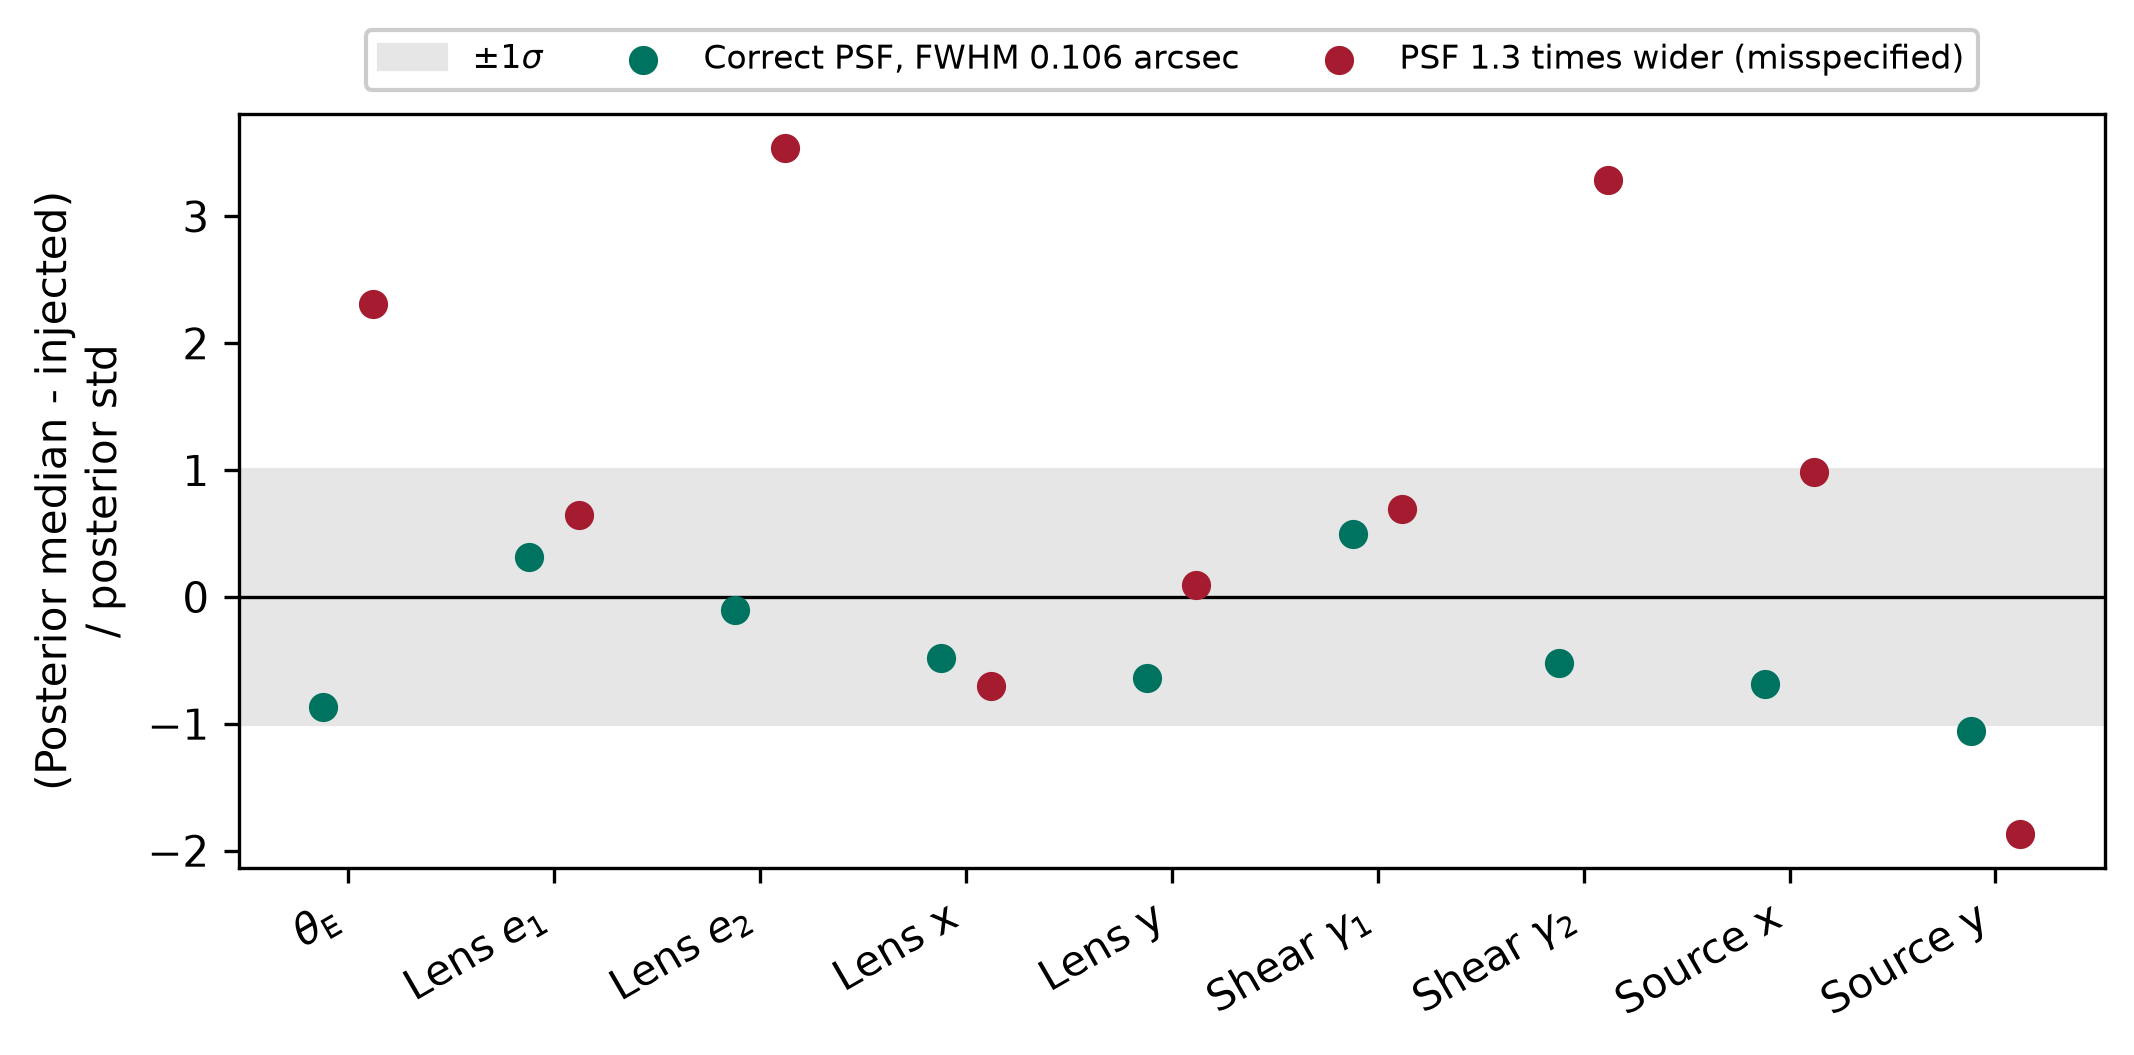

In [2]:
for path in summary['figure_paths']:
    display(Image(filename=str(path)))